# Auto Workflow Probe Reproducibility Notebook

Problem class: ANA

This notebook reproduces the tiny free-dispersive probe used to validate the staged research loop. The headline result is that free dispersive idle evolution reaches a relative excited-branch phase of $\pi$ between the cavity $n=0$ and $n=1$ manifolds at $t_{\pi} = \pi/|\chi|$, which is $176.056338$ ns for $\chi/2\pi = -2.84$ MHz. The default path reloads the saved JSON and CSV outputs and re-plots the reported figure.

## Environment Setup

This cell imports the minimal packages needed for the lightweight load-first workflow and resolves all study-relative paths from the notebook location.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_PATH = Path.cwd() / 'reproducibility_notebook.ipynb'
if not NOTEBOOK_PATH.exists():
    NOTEBOOK_PATH = Path.cwd()

STUDY_ROOT = NOTEBOOK_PATH.resolve().parents[1] if NOTEBOOK_PATH.suffix == '.ipynb' else Path.cwd().resolve().parents[0]
DATA_PATH = STUDY_ROOT / 'data' / 'phase_difference_samples.csv'
ARTIFACT_PATH = STUDY_ROOT / 'artifacts' / 'free_dispersive_pi_probe_summary.json'
FIGURE_PNG_PATH = STUDY_ROOT / 'figures' / 'phase_difference_vs_idle_time.png'
FIGURE_PDF_PATH = STUDY_ROOT / 'figures' / 'phase_difference_vs_idle_time.pdf'

print(f'Study root: {STUDY_ROOT}')
print(f'Artifact path exists: {ARTIFACT_PATH.exists()}')
print(f'Data path exists: {DATA_PATH.exists()}')

Study root: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\auto_workflow_probe
Artifact path exists: True
Data path exists: True


## User-Tunable Parameters

All adjustable knobs for this probe live in the next code cell. Changing them and then re-running the derived-objects cell is sufficient to propagate the new settings to the optional rerun path.

In [2]:
CHI_HZ = -2.84e6
CAVITY_DIMS = (2, 3)
QUBIT_DIM = 2
NUM_SAMPLES_EXPECTED = 51
RELOAD_SAVED_RESULTS_BY_DEFAULT = True

print('Configuration summary')
print(f'  chi / 2pi: {CHI_HZ / 1.0e6:.3f} MHz')
print(f'  cavity truncations: {CAVITY_DIMS}')
print(f'  qubit truncation: {QUBIT_DIM}')
print(f'  expected samples: {NUM_SAMPLES_EXPECTED}')
print(f'  default mode: load saved results = {RELOAD_SAVED_RESULTS_BY_DEFAULT}')

Configuration summary
  chi / 2pi: -2.840 MHz
  cavity truncations: (2, 3)
  qubit truncation: 2
  expected samples: 51
  default mode: load saved results = True


## Derived Objects

This cell builds the derived quantities used everywhere downstream, including the analytic $t_{\pi}$ and the canonical study paths. Re-running just the parameter cell and this cell is enough to update the optional rerun path.

In [3]:
TWO_PI = 2.0 * math.pi
CHI_RAD_S = TWO_PI * CHI_HZ
T_PI_S = math.pi / abs(CHI_RAD_S)
T_PI_NS = T_PI_S * 1.0e9

print(f'Analytic t_pi: {T_PI_NS:.6f} ns')
print(f'CSV path: {DATA_PATH}')
print(f'JSON path: {ARTIFACT_PATH}')

Analytic t_pi: 176.056338 ns
CSV path: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\auto_workflow_probe\data\phase_difference_samples.csv
JSON path: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\auto_workflow_probe\artifacts\free_dispersive_pi_probe_summary.json


## Step-by-Step Reproduction: Load Saved Results

This is the fast path used by default. It loads the saved JSON artifact and CSV phase samples, then prints the key values that should match the report: $t_{\pi} = 176.056338$ ns, a machine-precision analytic mismatch, and zero wrapped difference between the two cavity truncations.

In [4]:
# --- Load saved results (default) ---
artifact = json.loads(ARTIFACT_PATH.read_text(encoding='ascii'))
samples = np.genfromtxt(DATA_PATH, delimiter=',', names=True)

print(f"Artifact t_pi (ns): {artifact['analytic']['t_pi_ns']:.6f}")
print(f"Analytic t_pi from parameter cell (ns): {T_PI_NS:.6f}")
print(f"Wrapped analytic mismatch (rad): {artifact['numerical']['max_wrapped_error_dim2_rad']:.3e}")
print(f"Wrapped truncation difference (rad): {artifact['numerical']['max_wrapped_difference_dim2_vs_dim3_rad']:.3e}")
print(f"Loaded sample count: {samples.shape[0]}")

Artifact t_pi (ns): 176.056338
Analytic t_pi from parameter cell (ns): 176.056338
Wrapped analytic mismatch (rad): 8.882e-16
Wrapped truncation difference (rad): 0.000e+00
Loaded sample count: 51


## Optional Rerun Path

The next cell is intentionally commented out. It shows how to recompute the same minimal result with the current parameter cell, but the notebook defaults to loading saved outputs so the handoff remains fast and lightweight.

In [ ]:
# --- Re-run with current parameters ---
# from cqed_sim.core.model import DispersiveTransmonCavityModel
# from cqed_sim.gates.coupled import dispersive_phase
# 
# def wrap_phase(values):
#     return (np.asarray(values, dtype=float) + math.pi) % (2.0 * math.pi) - math.pi
# 
# times_s = np.linspace(0.0, 2.0 * T_PI_S, NUM_SAMPLES_EXPECTED)
# analytic_phase = -CHI_RAD_S * times_s
# numerical_traces = {}
# for cavity_dim in CAVITY_DIMS:
#     model = DispersiveTransmonCavityModel(
#         omega_q=2.0 * math.pi * 6.150e9,
#         omega_c=2.0 * math.pi * 5.241e9,
#         alpha=2.0 * math.pi * (-255.0e6),
#         chi=CHI_RAD_S,
#         kerr=2.0 * math.pi * (-28.0e3),
#         n_cav=int(cavity_dim),
#         n_tr=QUBIT_DIM,
#     )
#     excited_zero = model.basis_state(1, 0)
#     excited_one = model.basis_state(1, 1)
#     phases = []
#     for time_s in times_s:
#         unitary = dispersive_phase(
#             chi=CHI_RAD_S,
#             time=float(time_s),
#             cavity_dim=int(cavity_dim),
#             qubit_dim=QUBIT_DIM,
#             convention='n_e',
#         )
#         amplitude_zero = complex(excited_zero.overlap(unitary * excited_zero))
#         amplitude_one = complex(excited_one.overlap(unitary * excited_one))
#         phases.append(float(np.angle(amplitude_one * np.conjugate(amplitude_zero))))
#     numerical_traces[cavity_dim] = np.unwrap(np.asarray(phases, dtype=float))
# 
# print('Recomputed wrapped analytic mismatch:', np.max(np.abs(wrap_phase(numerical_traces[2] - analytic_phase))))

## Validation

This cell reproduces the small validation gate from the saved outputs. The expected outcome is that the first sample is zero phase, the sample at the analytic crossing is $\pi$, the analytic mismatch is at machine precision, and the two cavity truncations agree after phase wrapping.

In [5]:
def wrap_phase(values):
    return (np.asarray(values, dtype=float) + math.pi) % (2.0 * math.pi) - math.pi

analytic_phase = samples['analytic_phase_rad']
numerical_dim2 = samples['numerical_phase_dim2_rad']
numerical_dim3 = samples['numerical_phase_dim3_rad']
time_ns = samples['time_ns']

zero_phase_ok = abs(float(analytic_phase[0])) < 1.0e-15
closest_index = int(np.argmin(np.abs(time_ns - T_PI_NS)))
pi_phase = float(analytic_phase[closest_index])
max_wrapped_error = float(np.max(np.abs(wrap_phase(numerical_dim2 - analytic_phase))))
max_wrapped_dim_difference = float(np.max(np.abs(wrap_phase(numerical_dim3 - numerical_dim2))))

print(f'Zero phase at t=0: {zero_phase_ok}')
print(f'Closest loaded pi sample (rad): {pi_phase:.12f}')
print(f'Max wrapped analytic mismatch (rad): {max_wrapped_error:.3e}')
print(f'Max wrapped truncation difference (rad): {max_wrapped_dim_difference:.3e}')
assert zero_phase_ok
assert abs(pi_phase - math.pi) < 1.0e-12
assert max_wrapped_error < 1.0e-12
assert max_wrapped_dim_difference < 1.0e-12

Zero phase at t=0: True
Closest loaded pi sample (rad): 3.141592653590
Max wrapped analytic mismatch (rad): 0.000e+00
Max wrapped truncation difference (rad): 0.000e+00


## Key Figure

This cell regenerates the single publication figure directly from the saved CSV data so the visual evidence can be checked without re-running the study script.

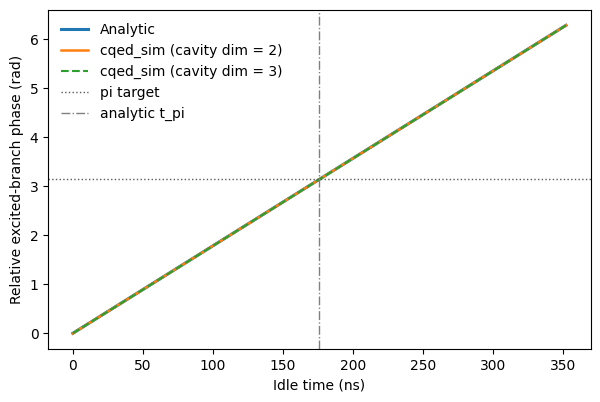

In [6]:
figure, axis = plt.subplots(figsize=(7.0, 4.4))
axis.plot(time_ns, analytic_phase, label='Analytic', linewidth=2.2)
axis.plot(time_ns, numerical_dim2, label='cqed_sim (cavity dim = 2)', linewidth=1.8)
axis.plot(time_ns, numerical_dim3, label='cqed_sim (cavity dim = 3)', linewidth=1.5, linestyle='--')
axis.axhline(math.pi, color='0.35', linestyle=':', linewidth=1.0, label='pi target')
axis.axvline(T_PI_NS, color='0.5', linestyle='-.', linewidth=1.0, label='analytic t_pi')
axis.set_xlabel('Idle time (ns)')
axis.set_ylabel('Relative excited-branch phase (rad)')
axis.legend(frameon=False)
plt.show()

## Summary

The notebook reproduced the saved probe outputs without any heavy recomputation. The load-first path confirms the analytic result $t_{\pi} = \pi/|\chi|$, the saved artifact value of $176.056338$ ns, a machine-precision analytic mismatch, and zero wrapped difference between the two cavity truncations used for the minimal convergence check.

| Tunable parameter | Default value | Effect on results |
| --- | --- | --- |
| `CHI_HZ` | `-2.84e6` | Sets the phase slope and therefore the analytic crossing time $t_{\pi} = \pi/|\chi|$. |
| `CAVITY_DIMS` | `(2, 3)` | Controls the minimal truncation comparison used for the convergence check. |
| `QUBIT_DIM` | `2` | Fixes the qubit truncation for the helper-based idle evolution. |
| `NUM_SAMPLES_EXPECTED` | `51` | Determines the sampling density in the saved idle-time scan. |
| `RELOAD_SAVED_RESULTS_BY_DEFAULT` | `True` | Keeps the notebook fast by preferring the saved artifact and CSV over recomputation. |